In [1]:
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt

from plotting import *

2026-07-06 12:52:28.980111: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
training_names = ["Transformer0e_2bit","Transformer40e_2bit", "Transformer80e_2bit","Transformer120e_2bit","Transformer240e_2bit","Transformer0e_3bit", "Transformer40e_3bit","Transformer80e_3bit","Transformer120e_3bit"]

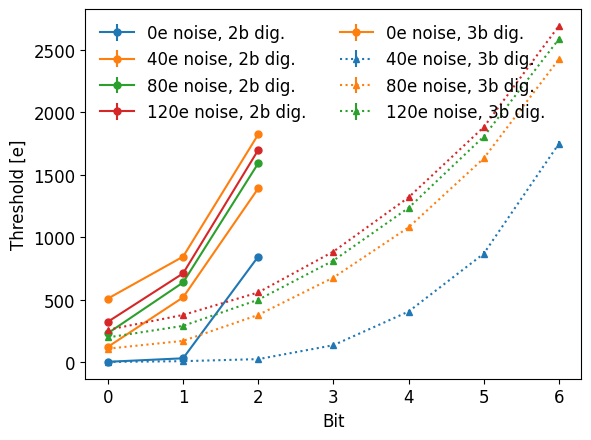

In [3]:
lines = []
for t in training_names:
    df = pd.read_parquet("avg_thr_"+t+".parquet")

    bits = [0,1,2]
    marker = 'o'
    color = "tab:blue"
    ls = '-'

    if '3bit' in t:
        bits = [0,1,2,3,4,5,6]
        marker = '^'
        ls = ':'
    
    if '40e' in t:
        color='tab:orange'
    elif '80e' in t:
        color = 'tab:green'
    elif '120e' in t:
        color = 'tab:red'

    #print(t, df['mean'].astype('int'))
    
    lines += plt.errorbar(x=bits, y=df['mean'], yerr=df['sigma'], linestyle=ls,marker=marker,ms=5,label=t, color=color)
    
plt.xlabel('Bit')
plt.ylabel('Threshold [e]')

labels = ['0e noise, 2b dig.','40e noise, 2b dig.','80e noise, 2b dig.','120e noise, 2b dig.',
          '0e noise, 3b dig.','40e noise, 3b dig.','80e noise, 3b dig.','120e noise, 3b dig.']

plt.legend(labels=labels,ncols=2,frameon=False);

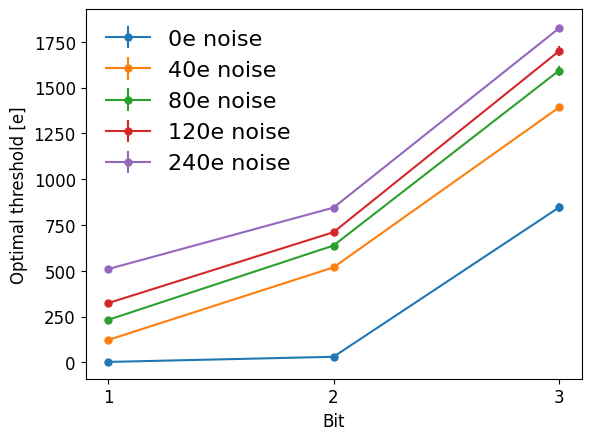

In [4]:
lines = []
for t in training_names:
    df = pd.read_parquet("avg_thr_"+t+".parquet")

    bits = [1,2,3]
    marker = 'o'
    color = "tab:blue"
    ls = '-'

    if '240e' in t:
        color = 'tab:purple'
    elif '40e' in t:
        color='tab:orange'
    elif '80e' in t:
        color = 'tab:green'
    elif '120e' in t:
        color = 'tab:red'


    #print(t, df['mean'].astype('int'))

    if '2bit' in t:
        lines += plt.errorbar(x=bits, y=df['mean'], yerr=df['sigma'], linestyle=ls,marker=marker,ms=5,label=t, color=color)
    
plt.xlabel('Bit')
plt.xticks([1,2,3])
plt.ylabel('Optimal threshold [e]')

labels = ['0e noise','40e noise','80e noise','120e noise','240e noise']

plt.legend(labels=labels,ncols=1,frameon=False,fontsize=fontsize);

In [10]:
training_names = ["Transformer0e_2bit","MaxConv2D_SQ_0e_2bit", "SlimConv2D_SQ_0e_2bit",
                  "Transformer40e_2bit", "MaxConv2D_SQ_40e_2bit", "SlimConv2D_SQ_40e_2bit",
                  "Transformer80e_2bit","MaxConv2D_SQ_80e_2bit", "SlimConv2D_SQ_80e_2bit",
                  "Transformer120e_2bit","MaxConv2D_SQ_120e_2bit", "SlimConv2D_SQ_120e_2bit",
                  "Transformer240e_2bit"]#,"MaxConv2D_SQ_120e_2bit", "SlimConv2D_SQ_120e_2bit",]

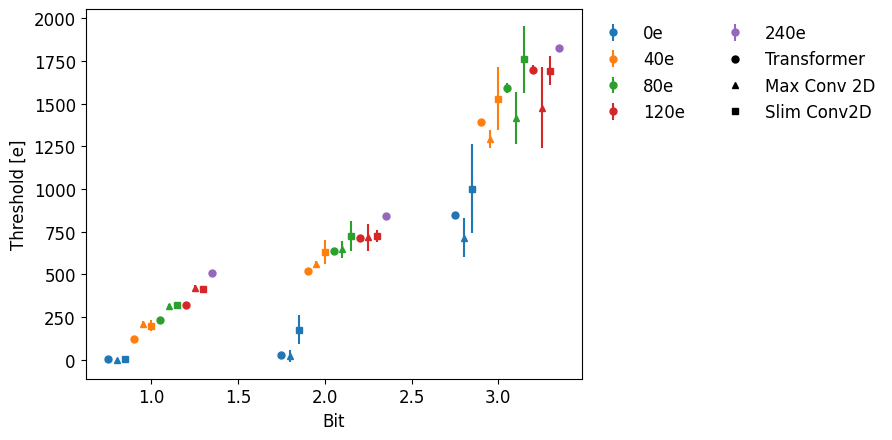

In [12]:
lines = []

bits = [0.7,1.7,2.7]
for t in training_names:
    df = pd.read_parquet("avg_thr_"+t+".parquet")

    bits = [b + 0.05 for b in bits]
    marker = 'o'
    color = "tab:blue"
    ls = '-'

    if 'MaxConv2D' in t:
        marker = '^'
        ls = ':'
    if 'SlimConv2D' in t:
        marker = 's'
        ls = ':'

    if '240e' in t:
        color='tab:purple'
    elif '40e' in t:
        color='tab:orange'
    elif '80e' in t:
        color = 'tab:green'
    elif '120e' in t:
        color = 'tab:red'

    #print(t, df['mean'].astype('int'))
    
    lines += [plt.errorbar(x=bits, y=df['mean'], yerr=df['sigma'], linestyle='',marker=marker,ms=5,label=t, color=color)]

plt.xlabel('Bit')
plt.ylabel('Threshold [e]')

proxy_line1 = matplotlib.lines.Line2D([0], [0], color='black', marker='o', ms=5, linestyle='')
proxy_line2 = matplotlib.lines.Line2D([0], [0], color='black', marker='^', ms=5, linestyle='')
proxy_line3 = matplotlib.lines.Line2D([0], [0], color='black', marker='s', ms=5, linestyle='')

lines_architectures = [proxy_line1, proxy_line2, proxy_line3]

labels_architectures = ["Transformer", "Max Conv 2D", "Slim Conv2D"]
lines_noiselevels = [lines[0], lines[3], lines[6], lines[9], lines[12]]
labels_noiselevels = ["0e", "40e", "80e", "120e", "240e"]

plt.legend(lines_noiselevels + lines_architectures, labels_noiselevels + labels_architectures,ncols=2,frameon=False,bbox_to_anchor=(1,1));


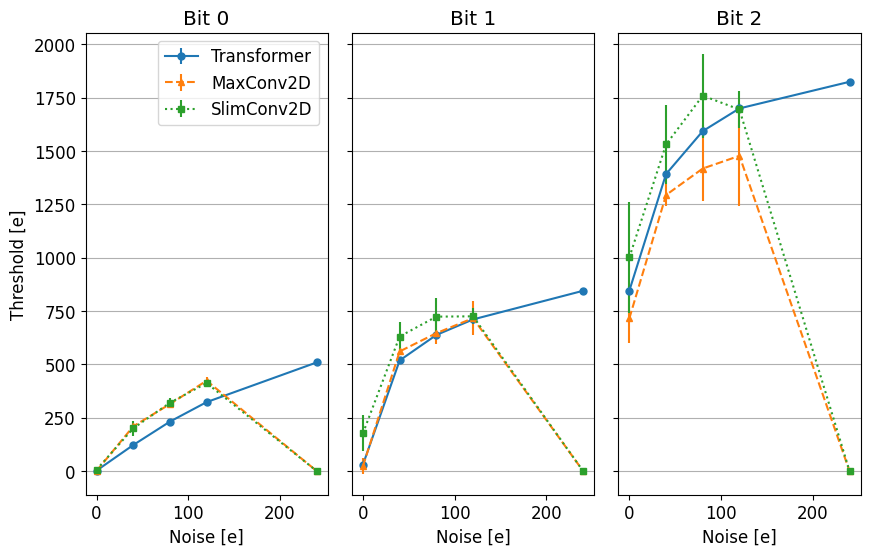

In [20]:
lines = []

noise = [0,40,80,120,240]

fig, ax = plt.subplots(1,3,figsize=(10,6),sharex=True,sharey=True,gridspec_kw={'wspace': 0.1})

labels = ["Transformer","MaxConv2D","SlimConv2D"]

for i,t in enumerate(["Transformer","MaxConv2D_SQ", "SlimConv2D_SQ"]):

    marker = 'o'
    color = "tab:blue"
    ls = '-'

    if 'MaxConv2D' in t:
        marker = '^'
        ls = '--'
        color='tab:orange'
        
    if 'SlimConv2D' in t:
        marker = 's'
        ls = ':'
        color = 'tab:green'

    bit_0_mean = []
    bit_1_mean = []
    bit_2_mean = []

    bit_0_std = []
    bit_1_std = []
    bit_2_std = []
    
    for n in noise:
        name = t + "_" + str(n) + "e_2bit"

        if "Transformer" in t:
            name = t + str(n) + "e_2bit"

        if not os.path.isfile("avg_thr_"+name+".parquet"):
            bit_0_mean += [0]
            bit_1_mean += [0]
            bit_2_mean += [0]

            bit_0_std += [0]
            bit_1_std += [0]
            bit_2_std += [0]
        else:
        
            df = pd.read_parquet("avg_thr_"+name+".parquet")
        
            bit_0_mean += [df['mean'].iloc[0]]
            bit_1_mean += [df['mean'].iloc[1]]
            bit_2_mean += [df['mean'].iloc[2]]

            bit_0_std += [df['sigma'].iloc[0]]
            bit_1_std += [df['sigma'].iloc[1]]
            bit_2_std += [df['sigma'].iloc[2]]

    ax[0].set_title("Bit 0")
    ax[0].errorbar(x=noise, y=bit_0_mean, yerr=bit_0_std, linestyle=ls, marker=marker, ms=5,label=labels[i], color=color)

    ax[1].set_title("Bit 1")
    ax[1].errorbar(x=noise, y=bit_1_mean, yerr=bit_1_std, linestyle=ls, marker=marker, ms=5,label=labels[i], color=color)

    ax[2].set_title("Bit 2")
    ax[2].errorbar(x=noise, y=bit_2_mean, yerr=bit_2_std, linestyle=ls, marker=marker, ms=5,label=labels[i], color=color)

ax[0].legend()
ax[0].set_xlabel('Noise [e]')
ax[1].set_xlabel('Noise [e]')
ax[2].set_xlabel('Noise [e]')
ax[0].set_ylabel('Threshold [e]')

ax[0].grid(axis='y')
ax[1].grid(axis='y')
ax[2].grid(axis='y')

plt.savefig('plot_thresholds.png',bbox_inches='tight')
plt.savefig('plot_thresholds.pdf',bbox_inches='tight')
